# Lab 9- Deep Learning Model
This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from IPython.display import display

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("TensorFlow/Keras is not installed in this environment. Install tensorflow before running Lab 9.") from e

np.random.seed(42)
tf.random.set_seed(42)

C:\Users\zussa\miniconda3\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.1.0)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [2]:
filename = "../Lab.7/SUSY.csv"

VarNames = [
    "signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi",
    "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"
]

df = pd.read_csv(filename, dtype="float64", names=VarNames)

df = df.dropna().reset_index(drop=True)
df.head()

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


## Training and test samples

In [3]:
N_Max = 550000
N_Train = 500000

if len(df) < N_Max:
    N_Max = len(df)
    N_Train = int(0.90 * N_Max)

Train_Sample = df.iloc[:N_Train].copy()
Test_Sample = df.iloc[N_Train:N_Max].copy()

y_Train = Train_Sample["signal"].astype(int).to_numpy()
y_Test = Test_Sample["signal"].astype(int).to_numpy()

X_train_raw = Train_Sample.iloc[:, 1:9].to_numpy()
X_test_raw = Test_Sample.iloc[:, 1:9].to_numpy()

X_train_features = Train_Sample.iloc[:, 9:].to_numpy()
X_test_features = Test_Sample.iloc[:, 9:].to_numpy()

X_train_all = Train_Sample.iloc[:, 1:].to_numpy()
X_test_all = Test_Sample.iloc[:, 1:].to_numpy()

def scale_pair(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_raw_s, X_test_raw_s = scale_pair(X_train_raw, X_test_raw)
X_train_features_s, X_test_features_s = scale_pair(X_train_features, X_test_features)
X_train_all_s, X_test_all_s = scale_pair(X_train_all, X_test_all)

datasets = {
    "raw": (X_train_raw_s, X_test_raw_s),
    "features": (X_train_features_s, X_test_features_s),
    "all": (X_train_all_s, X_test_all_s)
}

for name, (Xtr, Xte) in datasets.items():
    print(name, Xtr.shape, Xte.shape)

raw (500000, 8) (50000, 8)
features (500000, 10) (50000, 10)
all (500000, 18) (50000, 18)


## Exercise 1

In [4]:
def build_dnn(input_dim, architecture="small"):
    if architecture == "small":
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid")
        ])
    elif architecture == "medium":
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.15),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid")
        ])
    elif architecture == "wide":
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.10),
            layers.Dense(32, activation="relu"),
            layers.Dense(1, activation="sigmoid")
        ])
    else:
        raise ValueError("architecture must be small, medium, or wide")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model


def plot_history(history, title):
    hist = history.history

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="test loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["auc"], label="train AUC")
    plt.plot(hist["val_auc"], label="test AUC")
    plt.xlabel("epoch")
    plt.ylabel("AUC")
    plt.title(title + " AUC")
    plt.legend()
    plt.show()

Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7224 - auc: 0.7888 - loss: 0.5464 - val_accuracy: 0.7779 - val_auc: 0.8483 - val_loss: 0.4732
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7874 - auc: 0.8583 - loss: 0.4568 - val_accuracy: 0.7898 - val_auc: 0.8609 - val_loss: 0.4523
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7942 - auc: 0.8656 - loss: 0.4445 - val_accuracy: 0.7931 - val_auc: 0.8649 - val_loss: 0.4456
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7970 - auc: 0.8685 - loss: 0.4394 - val_accuracy: 0.7949 - val_auc: 0.8672 - val_loss: 0.4417
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7984 - auc: 0.8701 - loss: 0.4367 - val_accuracy: 0.7959 - val_auc: 0.8685 - val_loss: 0.4395
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7994 - auc: 0.8711 - loss: 0.4350 - val_accuracy: 0.7966 - val_auc: 0.8694 - val_loss: 0.4381
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 

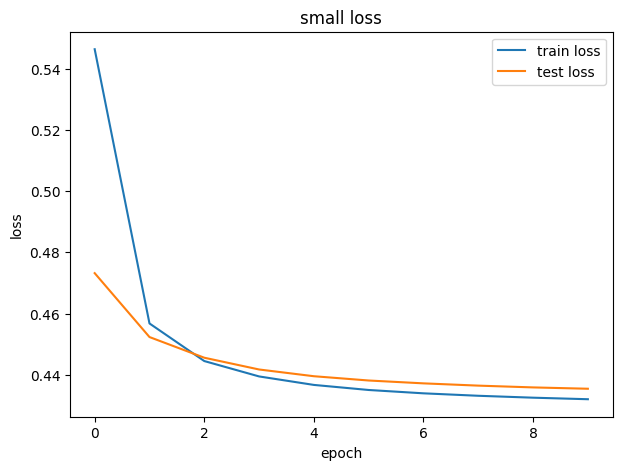

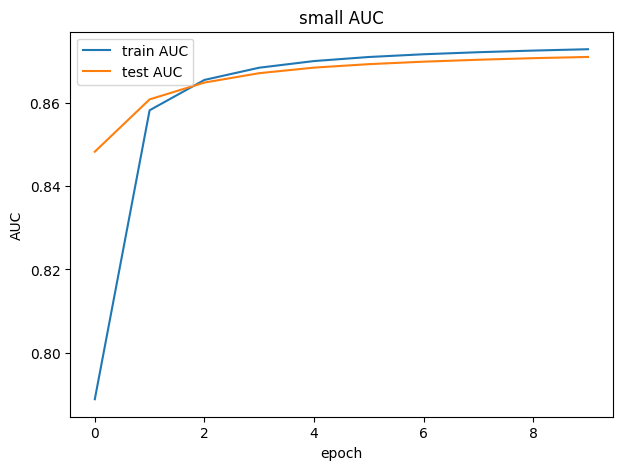

Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7610 - auc: 0.8293 - loss: 0.4974 - val_accuracy: 0.7927 - val_auc: 0.8635 - val_loss: 0.4485
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7912 - auc: 0.8614 - loss: 0.4501 - val_accuracy: 0.7961 - val_auc: 0.8678 - val_loss: 0.4414
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7950 - auc: 0.8656 - loss: 0.4434 - val_accuracy: 0.7974 - val_auc: 0.8692 - val_loss: 0.4388
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7966 - auc: 0.8674 - loss: 0.4407 - val_accuracy: 0.7985 - val_auc: 0.8702 - val_loss: 0.4371
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7981 - auc: 0.8686 - loss: 0.4386 - val_accuracy: 0.7983 - val_auc: 0.8707 - val_loss: 0.4363
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7985 - auc: 0.8697 - loss: 0.4370 - val_accuracy: 0.7983 - val_auc: 0.8710 - val_loss: 0.4356
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 

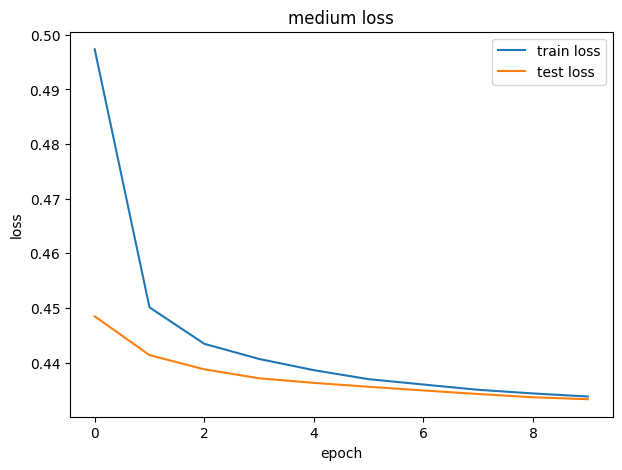

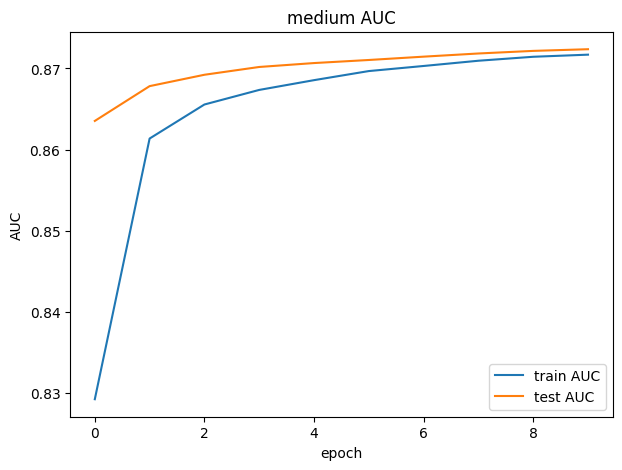

Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7688 - auc: 0.8381 - loss: 0.4851 - val_accuracy: 0.7953 - val_auc: 0.8666 - val_loss: 0.4436
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7940 - auc: 0.8640 - loss: 0.4453 - val_accuracy: 0.7977 - val_auc: 0.8694 - val_loss: 0.4384
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7969 - auc: 0.8672 - loss: 0.4405 - val_accuracy: 0.7980 - val_auc: 0.8705 - val_loss: 0.4364
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7983 - auc: 0.8689 - loss: 0.4381 - val_accuracy: 0.7982 - val_auc: 0.8712 - val_loss: 0.4353
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7996 - auc: 0.8703 - loss: 0.4360 - val_accuracy: 0.7988 - val_auc: 0.8717 - val_loss: 0.4343
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - auc: 0.8710 - loss: 0.4350 - val_accuracy: 0.7981 - val_auc: 0.8721 - val_loss: 0.4337
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 

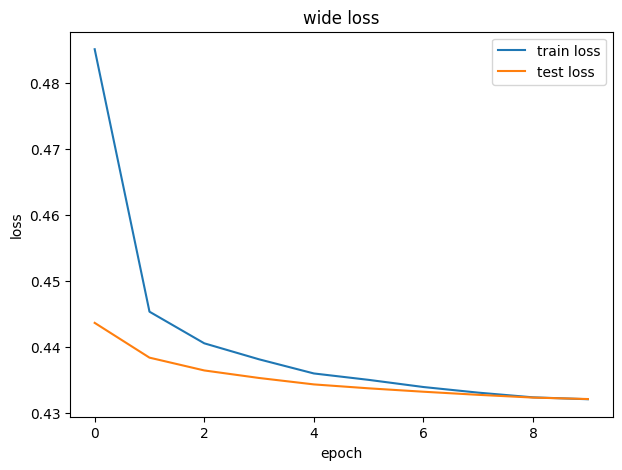

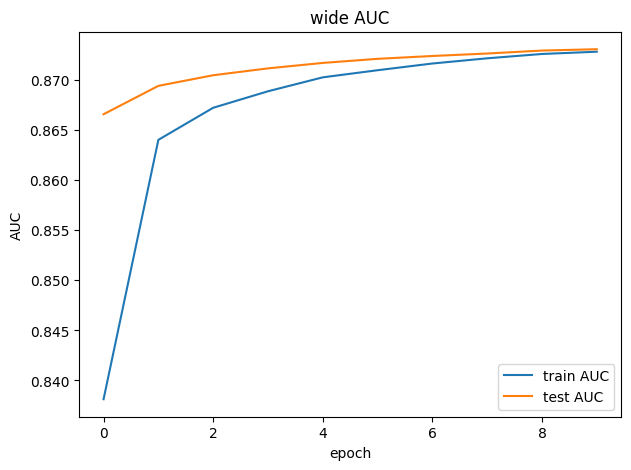

In [7]:
dnn_histories = {}
dnn_models = {}

for arch in ["small", "medium", "wide"]:
    model = build_dnn(X_train_all_s.shape[1], architecture=arch)
    history = model.fit(
        X_train_all_s, y_Train,
        validation_data=(X_test_all_s, y_Test),
        epochs=10,
        batch_size=4096,
        verbose=1
    )
    dnn_models[arch] = model
    dnn_histories[arch] = history
    plot_history(history, arch)

In [8]:
for arch, history in dnn_histories.items():
    train_auc = history.history["auc"][-1]
    test_auc = history.history["val_auc"][-1]
    gap = train_auc - test_auc
    print(arch, "train AUC =", round(train_auc, 4), "test AUC =", round(test_auc, 4), "gap =", round(gap, 4))

small train AUC = 0.873 test AUC = 0.8711 gap = 0.0019
medium train AUC = 0.8717 test AUC = 0.8724 gap = -0.0007
wide train AUC = 0.8728 test AUC = 0.8731 gap = -0.0002


## Exercise 2

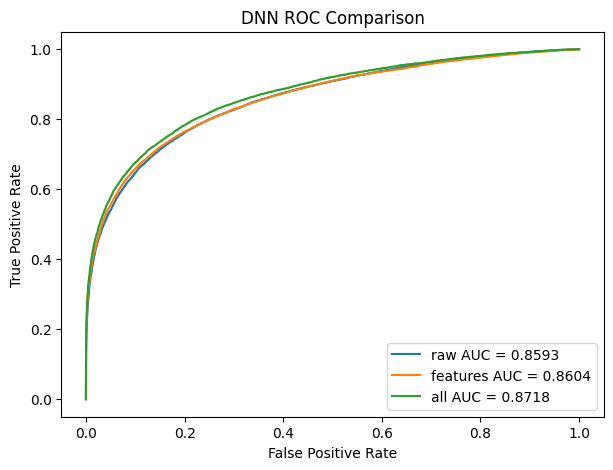

,dataset,AUC
0,raw,0.859349
1,features,0.860400
2,all,0.871791


In [9]:
def dnn_scores_for_dataset(architecture, Xtr, Xte, epochs=8):
    model = build_dnn(Xtr.shape[1], architecture=architecture)
    history = model.fit(
        Xtr, y_Train,
        validation_data=(Xte, y_Test),
        epochs=epochs,
        batch_size=4096,
        verbose=0
    )
    scores = model.predict(Xte, batch_size=4096, verbose=0).ravel()
    return model, history, scores

roc_rows = []
plt.figure(figsize=(7, 5))

exercise2_models = {}
exercise2_histories = {}
exercise2_scores = {}

for dname, (Xtr, Xte) in datasets.items():
    model, history, scores = dnn_scores_for_dataset("medium", Xtr, Xte, epochs=8)
    fpr_curve, tpr_curve, thresholds = roc_curve(y_Test, scores)
    roc_auc = auc(fpr_curve, tpr_curve)
    exercise2_models[dname] = model
    exercise2_histories[dname] = history
    exercise2_scores[dname] = scores
    roc_rows.append([dname, roc_auc])
    plt.plot(fpr_curve, tpr_curve, label=f"{dname} AUC = {roc_auc:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DNN ROC Comparison")
plt.legend(loc="lower right")
plt.show()

pd.DataFrame(roc_rows, columns=["dataset", "AUC"])

## Exercise 3

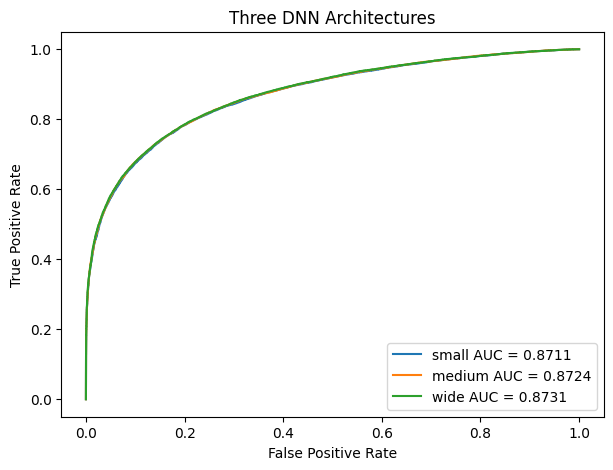

,architecture,AUC
2,wide,0.873115
1,medium,0.872396
0,small,0.871120


Best DNN: wide


In [10]:
architecture_rows = []

plt.figure(figsize=(7, 5))

for arch, model in dnn_models.items():
    scores = model.predict(X_test_all_s, batch_size=4096, verbose=0).ravel()
    fpr_curve, tpr_curve, thresholds = roc_curve(y_Test, scores)
    roc_auc = auc(fpr_curve, tpr_curve)
    architecture_rows.append([arch, roc_auc])
    plt.plot(fpr_curve, tpr_curve, label=f"{arch} AUC = {roc_auc:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Three DNN Architectures")
plt.legend(loc="lower right")
plt.show()

architecture_results = pd.DataFrame(architecture_rows, columns=["architecture", "AUC"]).sort_values("AUC", ascending=False)
display(architecture_results)

best_dnn_name = architecture_results.iloc[0]["architecture"]
best_dnn = dnn_models[best_dnn_name]
print("Best DNN:", best_dnn_name)

## Exercise 4

In [22]:
def get_score(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.predict(X)


def max_significance_from_scores(y_true, scores):
    fpr_curve, tpr_curve, thresholds = roc_curve(y_true, scores)
    Ns_total = np.sum(y_true == 1)
    Nb_total = np.sum(y_true == 0)
    Ns = tpr_curve * Ns_total
    Nb = fpr_curve * Nb_total
    sigma = Ns / np.sqrt(Ns + Nb + 1e-9)
    idx = np.argmax(sigma)
    return sigma[idx], thresholds[idx], fpr_curve, tpr_curve


def evaluate_scores(name, dname, y_true, scores):
    roc_sigma, threshold, fpr_curve, tpr_curve = max_significance_from_scores(y_true, scores)
    roc_auc = auc(fpr_curve, tpr_curve)
    preds = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    tpr_value = tp / (tp + fn + 1e-9)
    fpr_value = fp / (fp + tn + 1e-9)
    return {
        "model": name,
        "dataset": dname,
        "AUC": roc_auc,
        "best_threshold": threshold,
        "max_sigma": roc_sigma,
        "TPR": tpr_value,
        "FPR": fpr_value,
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "accuracy": accuracy_score(y_true, preds)
    }

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier

classic_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=75, max_depth=10, n_jobs=-1, random_state=42),
    "Fast Gradient Boosting": HistGradientBoostingClassifier(max_iter=75, max_leaf_nodes=31, random_state=42)
}

classic_limit = min(75000, len(y_Train))

comparison_rows = []
roc_cache = []

for model_name, model_template in classic_models.items():
    for dname, (Xtr, Xte) in datasets.items():
        Xtr_small = Xtr[:classic_limit]
        ytr_small = y_Train[:classic_limit]

        model = model_template.__class__(**model_template.get_params())
        model.fit(Xtr_small, ytr_small)

        scores = get_score(model, Xte)
        comparison_rows.append(evaluate_scores(model_name, dname, y_Test, scores))

        fpr_curve, tpr_curve, thresholds = roc_curve(y_Test, scores)
        roc_cache.append((model_name, dname, auc(fpr_curve, tpr_curve), fpr_curve, tpr_curve))

best_dnn_scores = best_dnn.predict(X_test_all_s, batch_size=4096, verbose=0).ravel()
comparison_rows.append(evaluate_scores("Best DNN", "all", y_Test, best_dnn_scores))

fpr_curve, tpr_curve, thresholds = roc_curve(y_Test, best_dnn_scores)
roc_cache.append(("Best DNN", "all", auc(fpr_curve, tpr_curve), fpr_curve, tpr_curve))

comparison_table = pd.DataFrame(comparison_rows).sort_values(["AUC", "max_sigma"], ascending=False)
display(comparison_table)

,model,dataset,AUC,best_threshold,max_sigma,TPR,FPR,precision,recall,F1,accuracy
9,Best DNN,all,0.873115,0.391096,118.022455,0.791411,0.207202,0.765010,0.791411,0.777987,0.79216
8,Fast Gradient Boosting,all,0.870946,-0.581116,117.806707,0.805755,0.230578,0.748647,0.805755,0.776152,0.78614
5,Random Forest,all,0.863421,0.392202,116.533969,0.778980,0.212277,0.757737,0.778980,0.768212,0.78370
7,Fast Gradient Boosting,features,0.858514,-0.574848,115.832793,0.790107,0.238951,0.738103,0.790107,0.763220,0.77442
6,Fast Gradient Boosting,raw,0.857596,-0.569579,115.993193,0.799018,0.249472,0.731895,0.799018,0.763985,0.77284
2,Logistic Regression,all,0.856177,-0.412371,115.463551,0.756465,0.196940,0.766021,0.756465,0.761213,0.78162
4,Random Forest,features,0.854457,0.374391,115.317803,0.774460,0.224354,0.746335,0.774460,0.760137,0.77510
3,Random Forest,raw,0.852619,0.378979,115.197320,0.788369,0.246471,0.731636,0.788369,0.758944,0.76956
1,Logistic Regression,features,0.830997,-0.623048,112.233425,0.788977,0.296595,0.693937,0.788977,0.738411,0.74278
0,Logistic Regression,raw,0.830453,-0.586194,111.961012,0.780415,0.287593,0.698149,0.780415,0.736993,0.74370


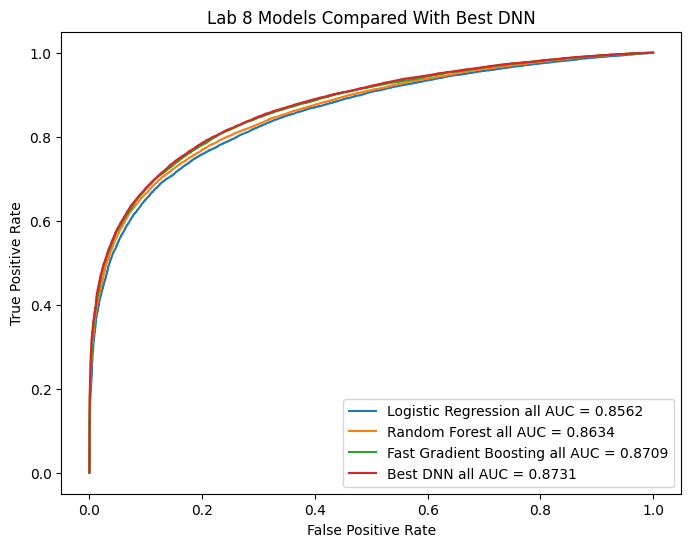

In [25]:
plt.figure(figsize=(8, 6))

for model_name, dname, roc_auc, fpr_curve, tpr_curve in roc_cache:
    if dname == "all":
        plt.plot(fpr_curve, tpr_curve, label=f"{model_name} {dname} AUC = {roc_auc:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Lab 8 Models Compared With Best DNN")
plt.legend(loc="lower right")
plt.show()